In [ ]:
import h5py
cache ='tmp/torgo/wavlm-basep-all/cache.hdf5'
file = h5py.File(cache, 'r')
for i in range(len(file)):
    if i == 1685:
        print(file[str(i)])

    shape = file[str(i)].shape
    if shape[0] != 12 and shape[-1] != 768:
        print(f"Index {i} has shape {shape}")

In [8]:
import torch
import matplotlib.pyplot as plt

scores = torch.load("exps/c9s_t1/wavlm-basep-last-chunkASP_LTprobe-upsampler-t0.1-regs-chunk4-frfr-ongod/brain-logs/final_model/test_diagnostics.pt")

tensor(0.0847)

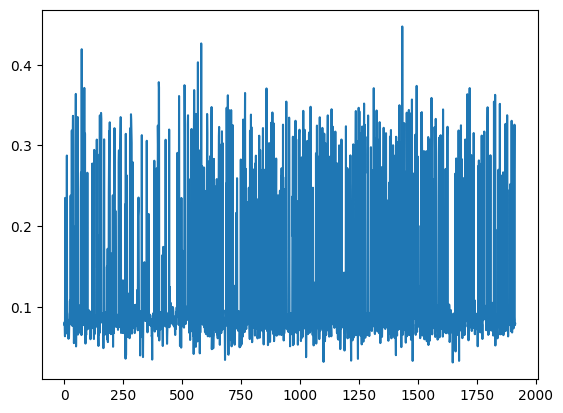

In [9]:
mean = []
for score in list(scores.values()):
    mean.append(score['boundary_prob'].float().mean().item())
plt.plot(mean)
torch.tensor(mean).mean().item()
torch.tensor(mean).median()

In [5]:
import plotly.graph_objects as go
score = list(scores.values())[2]
# Example inputs (replace with your real tensors / lists)
boundary_scores = torch.tensor(score['boundary_prob'][:,1])          # shape [T]
temporal_pool_scores = torch.tensor(score['scores'])  # shape [T]
temporal_pool_scores = torch.sigmoid(temporal_pool_scores)

threshold = 0.1
T = len(boundary_scores)
x = list(range(T))

# 1. Boundary crossings
cross_idx = torch.nonzero(boundary_scores >= threshold, as_tuple=False).squeeze(-1)
cross_y = boundary_scores[cross_idx].tolist()

# 2. Align temporal pool scores by order
tp = temporal_pool_scores.tolist()
k = min(len(cross_idx), len(tp))

cross_idx = cross_idx[:k]
cross_y = cross_y[:k]
tp = tp[:k]

# 3. Keep only temporal pool scores > 0
keep = [i for i, v in enumerate(tp) if v > 0.01]

final_x = cross_idx[keep].tolist()
final_y = [cross_y[i] for i in keep]
final_tp = [tp[i] for i in keep]

fig = go.Figure()

# Boundary scores
fig.add_trace(go.Scatter(
    x=x,
    y=boundary_scores.tolist(),
    mode="lines+markers",
    name="Boundary scores"
))

# Threshold line
fig.add_trace(go.Scatter(
    x=[0, T - 1],
    y=[threshold, threshold],
    mode="lines",
    line=dict(dash="dash"),
    name=f"Threshold = {threshold}"
))

# Filtered crossing points
fig.add_trace(go.Scatter(
    x=final_x,
    y=final_y,
    mode="markers+text",
    text=[f"{v:.2f}" for v in final_tp],
    textposition="top center",
    name="Crossings (temporal pool > 0)",
    hovertemplate=(
        "Index: %{x}<br>"
        "Boundary: %{y:.4f}<br>"
        "Temporal pool: %{text}"
        "<extra></extra>"
    )
))

fig.update_layout(
    xaxis_title="Time index",
    yaxis_title="Boundary score",
    template="plotly_white"
)

fig.show()

/var/folders/1h/b1q1trfs1f92kvmysh7jm86c0000gn/T/ipykernel_37235/2018859119.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  boundary_scores = torch.tensor(score['boundary_prob'][1])          # shape [T]


TypeError: len() of a 0-d tensor

In [ ]:
import re
import matplotlib.pyplot as plt

# 1. Read file
with open("exps/c9s_t1/wavlm-large-last-chunkTprobe-upsampler-0.1/speech-health-ai_213328.out", "r") as f:
    text = f.read()

# 2. Extract percentages
values = [float(x) for x in re.findall(r"Average batch reduction:\s*([\d.]+)%", text)]


# 3. Plot
plt.figure()
plt.plot(values)
plt.xlabel("Step")
plt.ylabel("Average batch reduction (%)")
plt.title("Average Batch Reduction Over Time")
plt.grid(True)
plt.show()

In [ ]:
lb_loss = [float(x) for x in re.findall(r"Load balancing loss:\s*([\d.]+)", text)]
plt.figure()
plt.plot(lb_loss)
plt.xlabel("Step")
plt.ylabel("loss")
plt.title("Load Balancing loss Over Time")
plt.grid(True)
plt.show()